# HOMEWORK 13 (lesson 14)

In this assignment, a classifier for the CIFAR-10 dataset is developed using a convolutional neural network. The work includes the following stages:

- Dataset inspection
- Building the network
- Training
- Evaluation

Additionally, several modifications of the model are explored in order to improve its performance, and their impact is analyzed.

In [48]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.layers import Conv2D, Dense, Flatten, Input, MaxPooling2D, BatchNormalization, Activation, Dropout, RandomFlip, RandomRotation, RandomZoom
from tensorflow.keras.utils import to_categorical, plot_model
from tensorflow.keras import Model
from time import time
import seaborn as sns

from matplotlib import pyplot as plt
plt.rcParams['figure.figsize'] = [15, 10]

# Set the seeds for reproducibility
from numpy.random import seed
from tensorflow.random import set_seed
seed_value = 1234578790
seed(seed_value)
set_seed(seed_value)

## Dataset Inspection

Load the dataset and make a quick inspection.

/tmp/ipykernel_57358/1588837029.py:18: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  plt.title(classes[int(y_train[idx])])


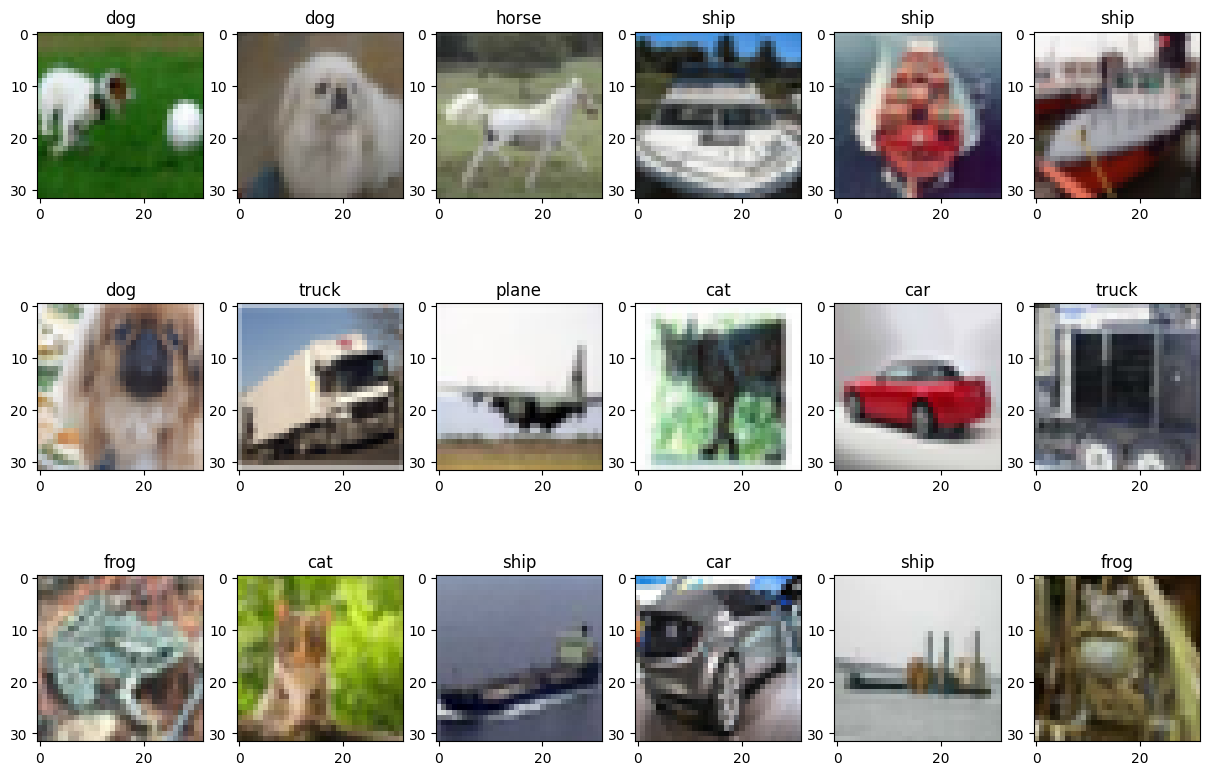

In [2]:
# Load the dataset
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()
# Mapping from class ID to class name
classes = {0:'plane', 1:'car', 2:'bird', 3:'cat', 4:'deer',
           5:'dog', 6:'frog', 7:'horse', 8:'ship', 9:'truck'}

# Dataset params
num_classes = len(classes)
size = x_train.shape[1]

# Visualize random samples (as a plot with 3x6 samples)
for ii in range(18):    
    plt.subplot(3,6,ii+1)
    # Pick a random sample
    idx = np.random.choice(len(x_train))
    # Show the image and the label
    plt.imshow(x_train[idx, ...])
    plt.title(classes[int(y_train[idx])])

The images appear highly pixelated and low in detail, making objects sometimes hard to distinguish. Many objects are not clearly centered and can be partially visible or shown from unusual angles. There is noticeable variation in how objects of the same class look, including differences in shape, pose, and context. Backgrounds are often complex and may distract from the main object. In some cases, different classes look visually similar, which can make recognition more difficult.

## Exploratory Data Analysis

In [3]:
def plot_train_test_distribution(y_train, y_test, classes):

    import pandas as pd
    import seaborn as sns

    train_counts = pd.Series(y_train.flatten()).value_counts().sort_index()
    test_counts = pd.Series(y_test.flatten()).value_counts().sort_index()

    class_names = [classes[i] for i in train_counts.index]

    train_df = pd.DataFrame({
        'ClassName': class_names,
        'Count': train_counts.values
    })

    test_df = pd.DataFrame({
        'ClassName': class_names,
        'Count': test_counts.values
    })

    palette = sns.color_palette("husl", len(classes))

    fig, axes = plt.subplots(1, 2, figsize=(16, 5), sharey=True)

    # train
    ax1 = sns.barplot(
        x='ClassName',
        y='Count',
        data=train_df,
        hue='ClassName',
        dodge=False,
        palette=palette,
        legend=False,
        ax=axes[0]
    )

    axes[0].set_title('Train distribution')
    axes[0].tick_params(axis='x', rotation=0)

    for i, v in enumerate(train_df['Count']):
        ax1.text(i, v + 20, str(v), ha='center', fontsize=8)

    # test
    ax2 = sns.barplot(
        x='ClassName',
        y='Count',
        data=test_df,
        hue='ClassName',
        dodge=False,
        palette=palette,
        legend=False,
        ax=axes[1]
    )

    axes[1].set_title('Test distribution')
    axes[1].tick_params(axis='x', rotation=45)

    for i, v in enumerate(test_df['Count']):
        ax2.text(i, v + 20, str(v), ha='center', fontsize=8)

    axes[0].set_ylabel('Number of Images')

    plt.tight_layout()
    plt.show()

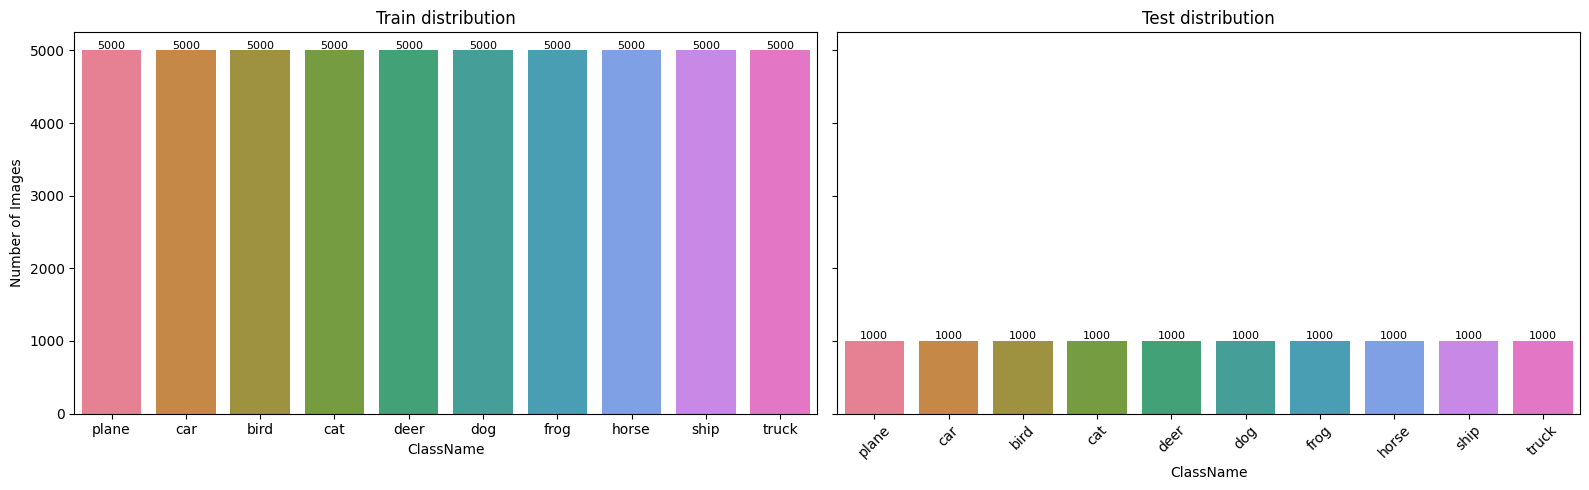

In [4]:
plot_train_test_distribution(y_train, y_test, classes)

The dataset is perfectly balanced. Each class contains exactly 5000 samples in the training set and 1000 samples in the test set. The distribution is uniform across all classes, with no class having more or fewer examples than others. This indicates that there is no class imbalance, and all categories are equally represented in both training and test data.

In [5]:
unique_shapes = set([img.shape for img in x_train])
print(unique_shapes)

{(32, 32, 3)}


The dataset consists of RGB images of fixed size 32×32 pixels. Since all images share the same dimensions, no resizing or aspect ratio normalization is needed.

In [7]:
def plot_brightness_analysis(x, y, classes):

    import numpy as np
    import pandas as pd
    import seaborn as sns
    import matplotlib.pyplot as plt

    sns.set_style("whitegrid")

    brightness = x.mean(axis=(1,2,3))

    df = pd.DataFrame({
        'Brightness': brightness,
        'ClassId': y.flatten()
    })

    df['ClassName'] = df['ClassId'].apply(lambda c: classes[c])

    palette = sns.color_palette("husl", len(classes))

    plt.figure(figsize=(20,12))


    plt.subplot(3,2,1)
    sns.histplot(df['Brightness'], bins=40, kde=True, color="#4C72B0")

    mean_val = df['Brightness'].mean()
    std_val = df['Brightness'].std()

    plt.axvline(mean_val, color='red', linestyle='--')
    plt.title(f'Brightness Distribution\nMean={mean_val:.3f}, Std={std_val:.3f}')
    plt.xlabel('Brightness')

    # Boxplot
    plt.subplot(3,2,2)
    sns.boxplot(
        x='ClassName',
        y='Brightness',
        data=df,
        hue='ClassName',
        palette=palette,
        legend=False
    )
    plt.xticks(rotation=45)
    plt.title('Brightness per Class')

    class_ids = sorted(df['ClassId'].unique())

    for i, cid in enumerate(class_ids):
        plt.subplot(3,5,6 + i)

        subset = df[df['ClassId'] == cid]

        sns.histplot(
            subset['Brightness'],
            bins=20,
            color=palette[i]
        )

        plt.title(classes[cid], fontsize=10)
        plt.xticks(fontsize=8)
        plt.yticks(fontsize=8)
        plt.xlabel('')
        plt.ylabel('')

    plt.tight_layout()
    plt.show()

/tmp/ipykernel_57358/164238296.py:66: UserWarning: tight_layout not applied: number of columns in subplot specifications must be multiples of one another.
  plt.tight_layout()


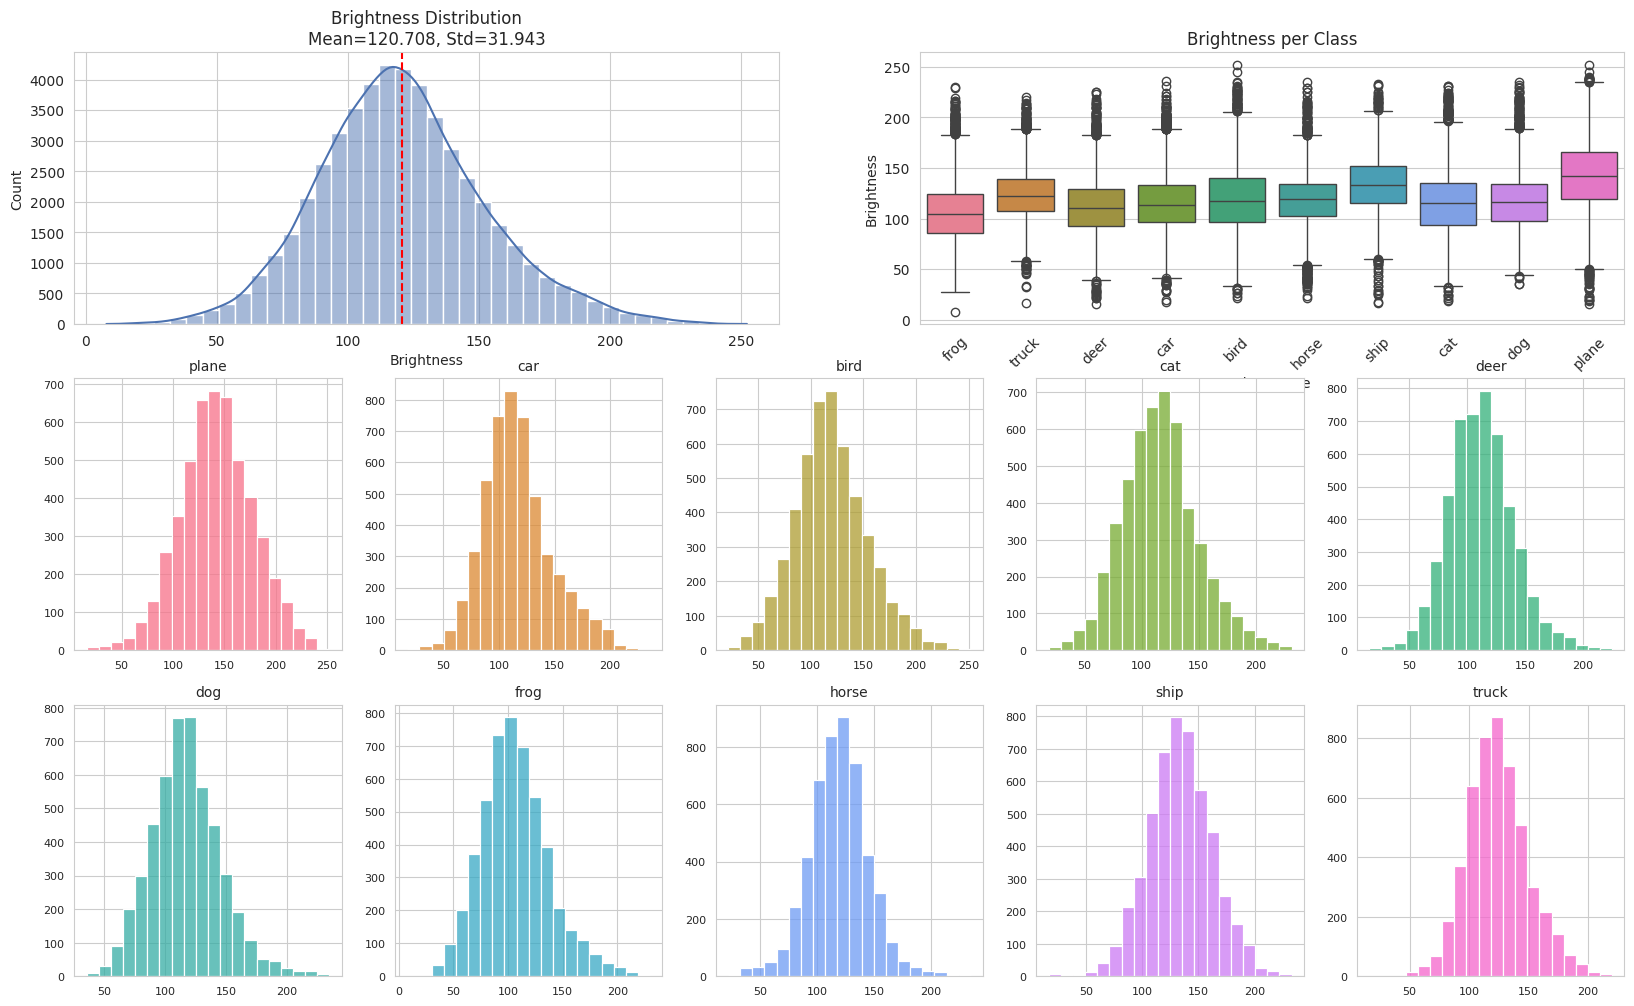

In [8]:
plot_brightness_analysis(x_train, y_train, classes)

The brightness distribution is approximately unimodal and smoothly distributed, with no extreme skewness or outliers. The mean brightness is centered around a moderate value, indicating that images are neither too dark nor too bright on average.

Across classes, the boxplots and histograms show similar distributions with comparable means and spreads. There are no significant shifts between classes, and no class exhibits systematically higher or lower brightness.

This indicates that the dataset is consistent in terms of illumination, and there is no class-dependent brightness bias.

## Data Preparation

In this step, the data is prepared for training. First, the input images are normalized to scale pixel values to the range [0,1], which helps stabilize and accelerate the learning process. Then, the class labels are converted into one-hot encoded vectors, which are required for multi-class classification using categorical cross-entropy loss.

In [9]:
# Normalization
x_train = x_train / 255.0
x_test = x_test / 255.0

# One-hot encoding
y_train = to_categorical(y_train, num_classes)
y_test = to_categorical(y_test, num_classes)

print('Train set:   ', len(y_train), 'samples')
print('Test set:    ', len(y_test), 'samples')
print('Sample dims: ', x_train.shape)

Train set:    50000 samples
Test set:     10000 samples
Sample dims:  (50000, 32, 32, 3)


## Model_1: Baseline CNN

### Building the Classifier

A simple convolutional neural network used as a reference model to establish baseline performance.

In [65]:
# Build the classifier
inputs = Input(shape=(size, size, 3))

net = Conv2D(16, kernel_size=(3, 3), activation="relu")(inputs)
net = MaxPooling2D(pool_size=(2, 2))(net)

net = Conv2D(32, kernel_size=(3, 3), activation="relu")(net)
net = MaxPooling2D(pool_size=(2, 2))(net)

net = Flatten()(net)
outputs = Dense(num_classes, activation="softmax")(net)

model_baseline = Model(inputs, outputs)

# Show the model
model_baseline.summary()

Model: "functional_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_11 (InputLayer)     │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_28 (Conv2D)              │ (None, 30, 30, 16)     │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_17 (MaxPooling2D) │ (None, 15, 15, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_29 (Conv2D)              │ (None, 13, 13, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_18 (MaxPooling2D) │ (None, 6, 6, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_8 (Flatten)             │ (None, 1152)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 10)             │        11,530 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,618 (64.91 KB)

 Trainable params: 16,618 (64.91 KB)

 Non-trainable params: 0 (0.00 B)

### Training model_baseline

In [11]:
epochs = 25
batch_size = 128

# Compile the model
model_baseline.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Train the model
history_baseline = model_baseline.fit(
    x_train,
    y_train,
    validation_split=0.1,
    epochs=epochs,
    batch_size=batch_size
)

Epoch 1/25
352/352 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.3848 - loss: 1.7159 - val_accuracy: 0.4516 - val_loss: 1.5600
Epoch 2/25
352/352 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.4893 - loss: 1.4495 - val_accuracy: 0.4918 - val_loss: 1.4586
Epoch 3/25
352/352 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.5318 - loss: 1.3362 - val_accuracy: 0.5302 - val_loss: 1.3354
Epoch 4/25
352/352 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.5578 - loss: 1.2602 - val_accuracy: 0.5588 - val_loss: 1.2587
Epoch 5/25
352/352 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.5798 - loss: 1.2003 - val_accuracy: 0.5788 - val_loss: 1.2084
Epoch 6/25
352/352 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.5985 - loss: 1.1511 - val_accuracy: 0.5952 - val_loss: 1.1651
Epoch 7/25
352/352 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - accuracy: 0.6133 - loss: 1.1113 - val_accuracy: 0.6082 - val_loss: 1.1301
Epoch 8/25
352/352 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - accuracy: 0.6245 - loss: 1.0789 - val_accu

In [12]:
def plot_training_history(history):
    import matplotlib.pyplot as plt

    h = history.history
    epochs = range(len(h['loss']))

    plt.figure(figsize=(12,5))

    # Loss
    plt.subplot(1,2,1)
    plt.plot(epochs, h['loss'], '.-', label='Train')
    plt.plot(epochs, h['val_loss'], '.-', label='Validation')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.title('Loss over Epochs')
    plt.grid(True)
    plt.legend()

    # Accuracy
    plt.subplot(1,2,2)
    plt.plot(epochs, h['accuracy'], '.-', label='Train')
    plt.plot(epochs, h['val_accuracy'], '.-', label='Validation')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.title('Accuracy over Epochs')
    plt.grid(True)
    plt.legend()

    train_acc = h['accuracy'][-1]
    val_acc = h['val_accuracy'][-1]

    plt.figtext(0.5, -0.05,
                f"Final Train Acc: {train_acc:.4f} | Validation Acc: {val_acc:.4f}",
                ha="center", fontsize=11)

    plt.tight_layout()
    plt.show()

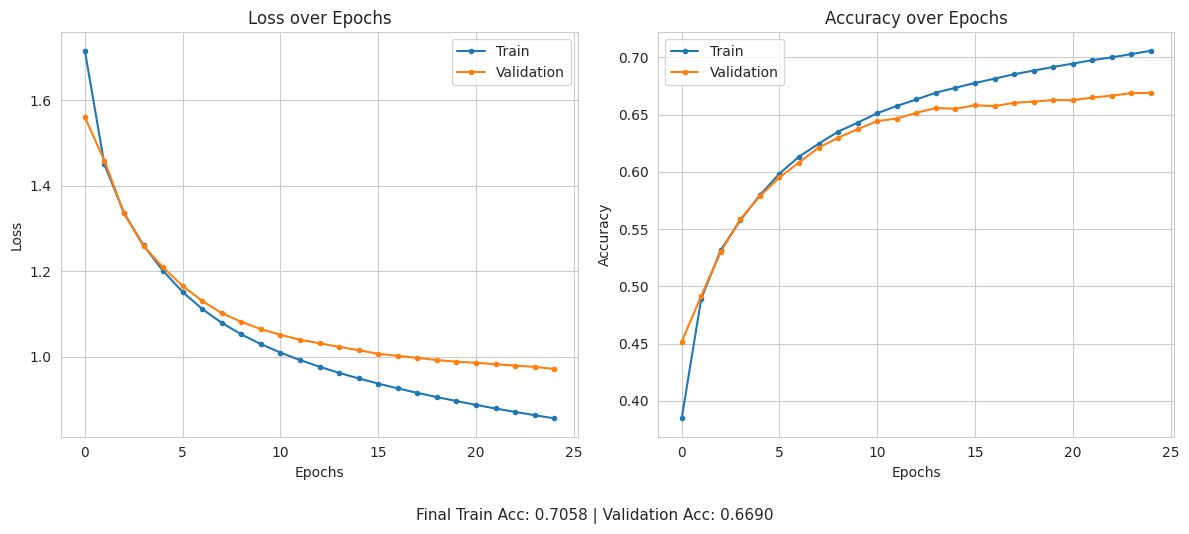

In [13]:
plot_training_history(history_baseline)

The model shows steady learning, with both training and validation loss decreasing over time. The gap between training and validation accuracy is small, indicating no strong overfitting. However, validation accuracy saturates earlier, suggesting limited model capacity.

### Evaluation

In this step, the trained model is evaluated using the test dataset, which was not seen during training. The evaluation includes computing overall and per-class accuracy, as well as visualizing correctly and incorrectly classified samples to better understand the model’s performance.

The validation set used during training was created from the training data via a validation split and was used to monitor the model during training. In contrast, the test set is used only for the final unbiased evaluation

In [14]:
# Compute the labels and the predictions as sparse values
y_true = np.argmax(y_test, axis=1)
y_pred_baseline = np.argmax(model_baseline.predict(x_test), axis=1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


In [15]:
def compute_class_accuracy(y_true, y_pred, classes):
    class_acc = {}

    for class_id, class_name in classes.items():
        
        idx = (y_true == class_id)
        
        if np.sum(idx) == 0:
            acc = 0.0
        else:
            acc = np.mean(y_pred[idx] == y_true[idx])
        
        class_acc[class_name] = acc

    df_class_acc = pd.DataFrame(
        list(class_acc.items()),
        columns=['Class', 'Accuracy']
    )

    df_class_acc = df_class_acc.sort_values(by='Accuracy', ascending=False).reset_index(drop=True)

    return df_class_acc

def plot_confusion_matrix(y_true, y_pred, classes):
    import numpy as np
    import matplotlib.pyplot as plt
    import seaborn as sns
    from sklearn.metrics import confusion_matrix

    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(8,6))

    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        xticklabels=classes.values(),
        yticklabels=classes.values()
    )

    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.title('Confusion Matrix')

    plt.xticks(rotation=0)
    plt.yticks(rotation=0)

    plt.tight_layout()
    plt.show()

def build_metrics_table(history, model, x_test, y_test):
    import pandas as pd

    train_loss = history.history['loss'][-1]
    train_acc = history.history['accuracy'][-1]

    val_loss = history.history['val_loss'][-1]
    val_acc = history.history['val_accuracy'][-1]

    test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)

    df = pd.DataFrame({
        'Dataset': ['Train', 'Validation', 'Test'],
        'Loss': [train_loss, val_loss, test_loss],
        'Accuracy': [train_acc, val_acc, test_acc]
    }).round(4)

    df = df.style.apply(
            lambda row: ['font-weight: bold'] * len(row) if row['Dataset'] == 'Test' else [''] * len(row),
            axis=1
        )

    return df

def show_predictions(x, y_true, y_pred, classes, mode='correct', n=15):

    plt.figure(figsize=(6,4))
    plt.tight_layout(h_pad=1.5, w_pad=3.0)

    if mode == 'correct':
        idxs = np.where(y_true == y_pred)[0]
        title = "Correct Predictions"
    elif mode == 'wrong':
        idxs = np.where(y_true != y_pred)[0]
        title = "Misclassified Samples"
    else:
        raise ValueError("mode must be 'correct' or 'wrong'")

    selected = np.random.choice(idxs, n, replace=False)

    for i, idx in enumerate(selected):
        plt.subplot(3,5,i+1)
        plt.imshow(x[idx])

        if mode == 'correct':
            plt.title(f"{classes[y_true[idx]]}")
        else:
            plt.title(f"T: {classes[y_true[idx]]} | P: {classes[y_pred[idx]]}", fontsize=10)

        plt.axis('off')

    plt.suptitle(title)
    plt.tight_layout()
    plt.show()


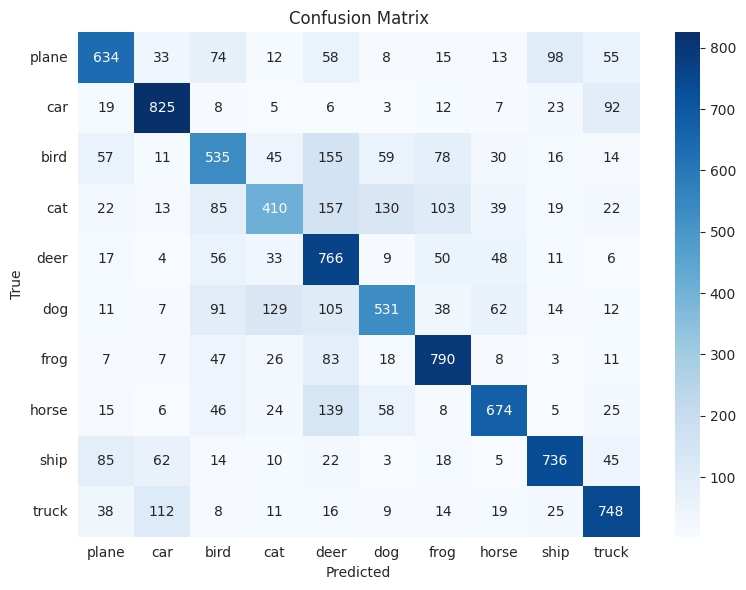

In [16]:
plot_confusion_matrix(y_true, y_pred_baseline, classes)

In [17]:
build_metrics_table(history_baseline, model_baseline, x_test, y_test)

,Dataset,Loss,Accuracy
0,Train,0.855200,0.705800
1,Validation,0.971000,0.669000
2,Test,0.993400,0.664900


In [18]:
class_accuracy = compute_class_accuracy(y_true, y_pred_baseline, classes)
class_accuracy

,Class,Accuracy
0,car,0.825
1,frog,0.790
2,deer,0.766
3,truck,0.748
4,ship,0.736
5,horse,0.674
6,plane,0.634
7,bird,0.535
8,dog,0.531
9,cat,0.410


#### Model1: Examples of Correct Predictions

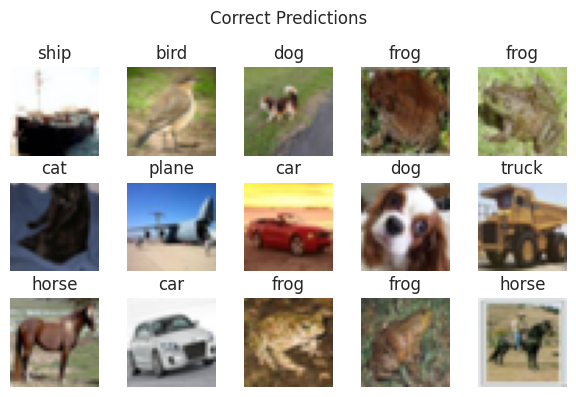

In [19]:
show_predictions(x_test, y_true, y_pred_baseline, classes, mode='correct')

#### Model1: Examples of Misclassified Samples

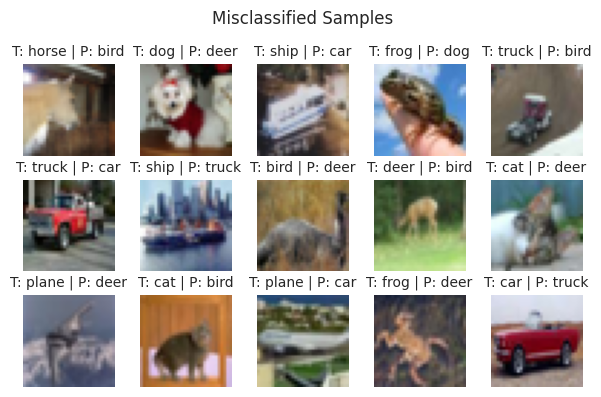

In [20]:
show_predictions(x_test, y_true, y_pred_baseline, classes, mode='wrong')

The baseline model achieves a test accuracy of 66.49%, indicating moderate performance on the CIFAR-10 dataset. The gap between training and test accuracy is relatively small, suggesting no strong overfitting and reasonable generalization. However, the model struggles with visually similar classes such as cat, dog, and bird, while performing better on more distinct classes like car and frog. This indicates that the current architecture has limited capacity and is not able to capture more complex visual patterns, motivating further improvements.

## Model 2: + Increased Filters

The number of filters is increased to allow the model to learn more complex and expressive features.

In [21]:
inputs = Input(shape=(size, size, 3))

net = Conv2D(32, kernel_size=(3, 3), activation="relu")(inputs)
net = MaxPooling2D(pool_size=(2, 2))(net)

net = Conv2D(64, kernel_size=(3, 3), activation="relu")(net)
net = MaxPooling2D(pool_size=(2, 2))(net)

net = Flatten()(net)
outputs = Dense(num_classes, activation="softmax")(net)

model_filters = Model(inputs, outputs)

model_filters.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │        23,050 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 42,442 (165.79 KB)

 Trainable params: 42,442 (165.79 KB)

 Non-trainable params: 0 (0.00 B)

In [22]:
epochs = 25
batch_size = 128

# Compile the model
model_filters.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Train the model
history_filters = model_filters.fit(
    x_train,
    y_train,
    validation_split=0.1,
    epochs=epochs,
    batch_size=batch_size
)

Epoch 1/25
352/352 ━━━━━━━━━━━━━━━━━━━━ 8s 21ms/step - accuracy: 0.4116 - loss: 1.6509 - val_accuracy: 0.5030 - val_loss: 1.4376
Epoch 2/25
352/352 ━━━━━━━━━━━━━━━━━━━━ 7s 21ms/step - accuracy: 0.5416 - loss: 1.3117 - val_accuracy: 0.5496 - val_loss: 1.3035
Epoch 3/25
352/352 ━━━━━━━━━━━━━━━━━━━━ 11s 30ms/step - accuracy: 0.5872 - loss: 1.1871 - val_accuracy: 0.5986 - val_loss: 1.1613
Epoch 4/25
352/352 ━━━━━━━━━━━━━━━━━━━━ 10s 29ms/step - accuracy: 0.6168 - loss: 1.1046 - val_accuracy: 0.6248 - val_loss: 1.0859
Epoch 5/25
352/352 ━━━━━━━━━━━━━━━━━━━━ 10s 28ms/step - accuracy: 0.6390 - loss: 1.0441 - val_accuracy: 0.6442 - val_loss: 1.0439
Epoch 6/25
352/352 ━━━━━━━━━━━━━━━━━━━━ 10s 28ms/step - accuracy: 0.6575 - loss: 0.9981 - val_accuracy: 0.6522 - val_loss: 1.0173
Epoch 7/25
352/352 ━━━━━━━━━━━━━━━━━━━━ 10s 29ms/step - accuracy: 0.6711 - loss: 0.9612 - val_accuracy: 0.6614 - val_loss: 0.9967
Epoch 8/25
352/352 ━━━━━━━━━━━━━━━━━━━━ 10s 29ms/step - accuracy: 0.6828 - loss: 0.9290 - va

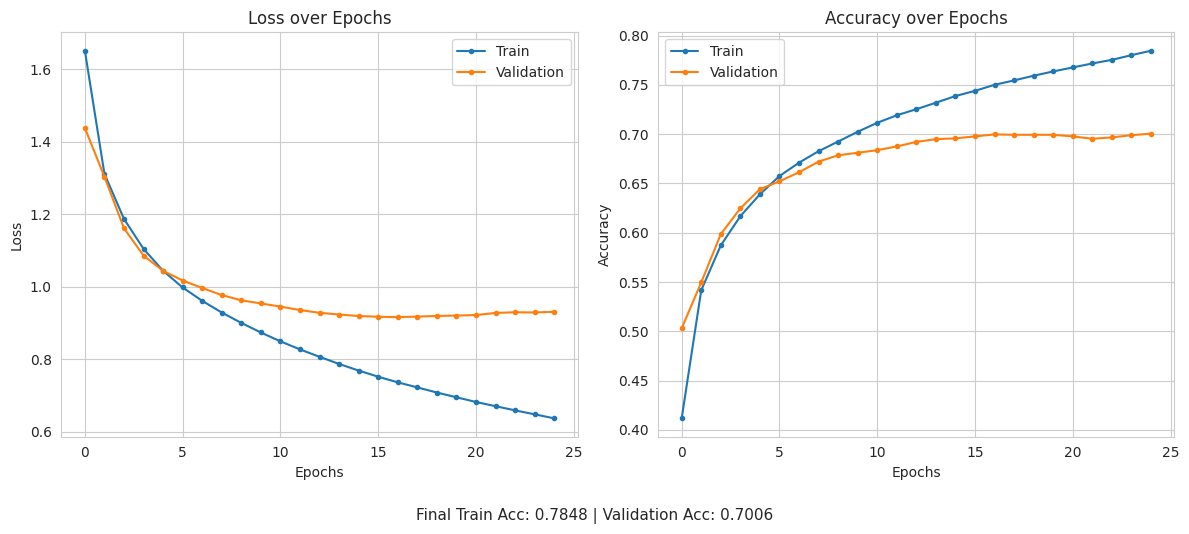

In [23]:
plot_training_history(history_filters)

Increasing the number of filters improves the model performance, raising validation accuracy from ~0.67 to ~0.70. The model learns more effectively and reaches a higher performance level compared to the baseline. However, a larger gap between training and validation accuracy appears, indicating the beginning of overfitting.

In [24]:
y_true = np.argmax(y_test, axis=1)
y_pred_filters = np.argmax(model_filters.predict(x_test), axis=1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


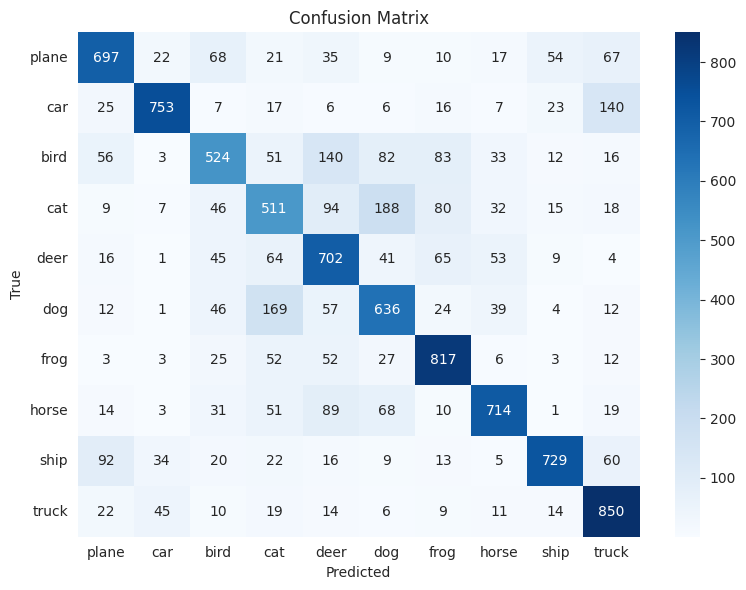

In [25]:
plot_confusion_matrix(y_true, y_pred_filters, classes)

In [26]:
build_metrics_table(history_filters, model_filters, x_test, y_test)

,Dataset,Loss,Accuracy
0,Train,0.637200,0.784800
1,Validation,0.931000,0.700600
2,Test,0.958000,0.693300


In [29]:
compute_class_accuracy(y_true, y_pred_filters, classes)

,Class,Accuracy
0,car,0.801
1,frog,0.773
2,ship,0.770
3,plane,0.761
4,truck,0.752
5,horse,0.752
6,deer,0.677
7,dog,0.625
8,bird,0.554
9,cat,0.455


#### Model2: Examples of Correct Predictions

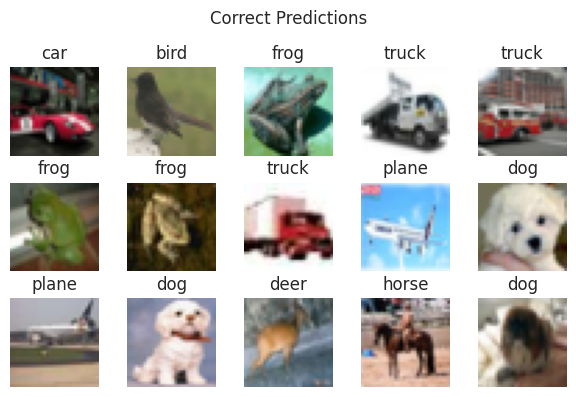

In [35]:
show_predictions(x_test, y_true, y_pred_filters, classes, mode='correct')

#### Model2: Examples of Misclassified Samples

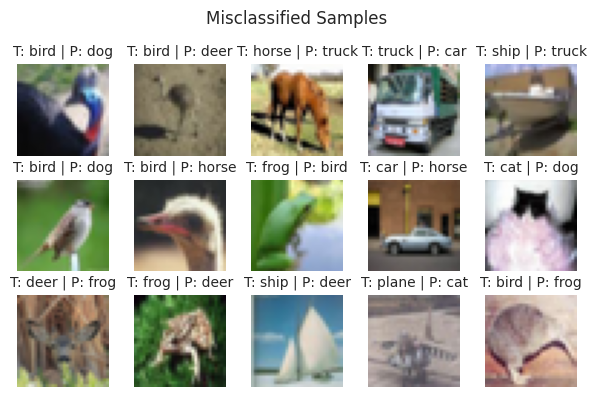

In [37]:
show_predictions(x_test, y_true, y_pred_filters, classes, mode='wrong')

The model with increased filters achieves a test accuracy of 69.3%, improving over the baseline and confirming that higher model capacity leads to better feature extraction. However, the gap between training and test accuracy indicates moderate overfitting. Performance improves across most classes, especially for distinct categories like car and frog, while confusion between similar classes such as cat, dog, and bird remains. Overall, the model benefits from increased capacity but requires further improvements in generalization.

## Model 3: + Batch Normalization

Batch Normalization is added to stabilize training and improve convergence.

In [27]:
inputs = Input(shape=(size, size, 3))

net = Conv2D(32, (3, 3))(inputs)
net = BatchNormalization()(net)
net = Activation("relu")(net)
net = MaxPooling2D((2, 2))(net)

net = Conv2D(64, (3, 3))(net)
net = BatchNormalization()(net)
net = Activation("relu")(net)
net = MaxPooling2D((2, 2))(net)

net = Flatten()(net)
outputs = Dense(num_classes, activation="softmax")(net)

model_bn = Model(inputs, outputs)

model_bn.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 30, 30, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 30, 30, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 13, 13, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 13, 13, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │        23,050 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 42,826 (167.29 KB)

 Trainable params: 42,634 (166.54 KB)

 Non-trainable params: 192 (768.00 B)

In [28]:
epochs = 25
batch_size = 128

# Compile the model
model_bn.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Train the model
history_bn = model_bn.fit(
    x_train,
    y_train,
    validation_split=0.1,
    epochs=epochs,
    batch_size=batch_size
)

Epoch 1/25
352/352 ━━━━━━━━━━━━━━━━━━━━ 15s 40ms/step - accuracy: 0.4952 - loss: 1.4327 - val_accuracy: 0.2634 - val_loss: 2.4291
Epoch 2/25
352/352 ━━━━━━━━━━━━━━━━━━━━ 18s 52ms/step - accuracy: 0.6280 - loss: 1.0638 - val_accuracy: 0.5342 - val_loss: 1.3478
Epoch 3/25
352/352 ━━━━━━━━━━━━━━━━━━━━ 18s 52ms/step - accuracy: 0.6696 - loss: 0.9536 - val_accuracy: 0.6068 - val_loss: 1.1274
Epoch 4/25
352/352 ━━━━━━━━━━━━━━━━━━━━ 18s 51ms/step - accuracy: 0.6945 - loss: 0.8826 - val_accuracy: 0.5952 - val_loss: 1.1325
Epoch 5/25
352/352 ━━━━━━━━━━━━━━━━━━━━ 18s 51ms/step - accuracy: 0.7136 - loss: 0.8281 - val_accuracy: 0.6124 - val_loss: 1.1332
Epoch 6/25
352/352 ━━━━━━━━━━━━━━━━━━━━ 18s 52ms/step - accuracy: 0.7320 - loss: 0.7832 - val_accuracy: 0.6540 - val_loss: 1.0229
Epoch 7/25
352/352 ━━━━━━━━━━━━━━━━━━━━ 19s 53ms/step - accuracy: 0.7458 - loss: 0.7450 - val_accuracy: 0.6290 - val_loss: 1.1059
Epoch 8/25
352/352 ━━━━━━━━━━━━━━━━━━━━ 19s 53ms/step - accuracy: 0.7581 - loss: 0.7120 - 

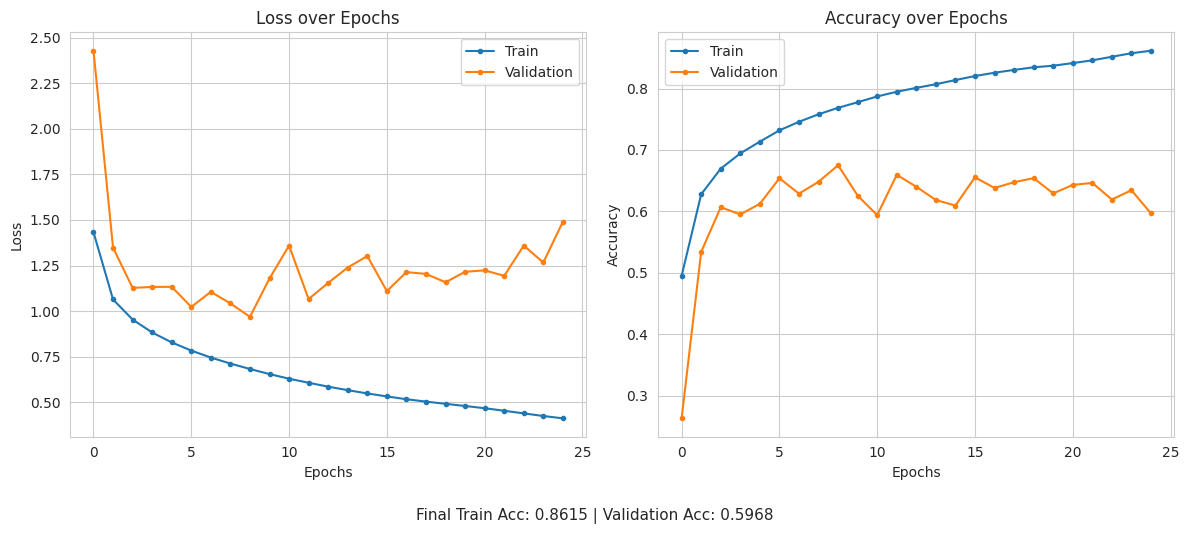

In [29]:
plot_training_history(history_bn)

The model with Batch Normalization shows unstable training behavior. While the training loss steadily decreases and training accuracy reaches a high value (86.2%), the validation performance fluctuates significantly and does not improve consistently. The validation accuracy peaks early and then decreases, while the validation loss starts increasing after several epochs. This indicates strong overfitting combined with unstable learning dynamics. Overall, the model fails to generalize well, and Batch Normalization does not provide a benefit in this configuration.

In [31]:
y_true = np.argmax(y_test, axis=1)
y_pred_bn = np.argmax(model_bn.predict(x_test), axis=1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


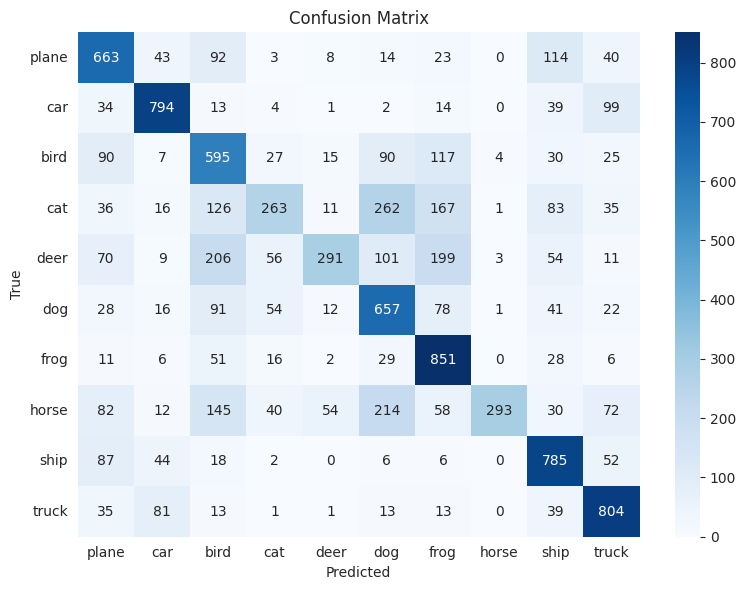

In [32]:
plot_confusion_matrix(y_true, y_pred_bn, classes)

In [33]:
build_metrics_table(history_bn, model_bn, x_test, y_test)

,Dataset,Loss,Accuracy
0,Train,0.411300,0.861500
1,Validation,1.490200,0.596800
2,Test,1.530500,0.599600


In [34]:
compute_class_accuracy(y_true, y_pred_bn, classes)

,Class,Accuracy
0,frog,0.851
1,truck,0.804
2,car,0.794
3,ship,0.785
4,plane,0.663
5,dog,0.657
6,bird,0.595
7,horse,0.293
8,deer,0.291
9,cat,0.263


#### Model3: Examples of Correct Predictions

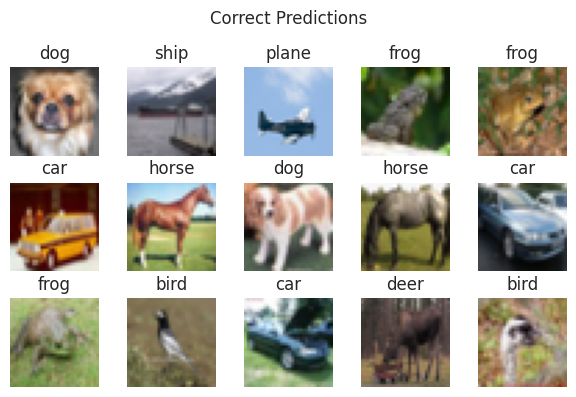

In [70]:
show_predictions(x_test, y_true, y_pred_bn, classes, mode='correct')

#### Model3: Examples of Misclassified Samples

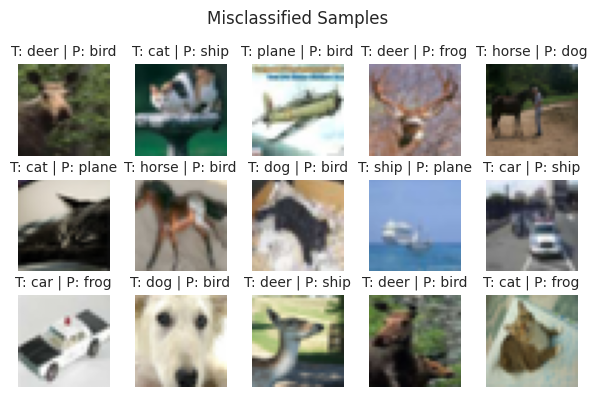

In [67]:
show_predictions(x_test, y_true, y_pred_bn, classes, mode='wrong')

Adding Batch Normalization did not improve the model performance and led to worse generalization on the test set. Although the training accuracy increased significantly, the validation and test accuracy decreased, indicating strong overfitting. The validation loss also became unstable and increased during training. This suggests that Batch Normalization was not suitable for this relatively simple architecture and negatively affected the learning dynamics. 

## Model 4: + Dropout Regularization

Dropout is introduced to reduce overfitting and improve model generalization.

In [ ]:
inputs = Input(shape=(32, 32, 3))

# Block 1
net = Conv2D(32, (3,3), activation='relu', padding='same')(inputs)
net = Conv2D(32, (3,3), activation='relu', padding='same')(net)
net = MaxPooling2D((2,2))(net)
net = Dropout(0.25)(net)

# Block 2
net = Conv2D(64, (3,3), activation='relu', padding='same')(net)
net = Conv2D(64, (3,3), activation='relu', padding='same')(net)
net = MaxPooling2D((2,2))(net)
net = Dropout(0.25)(net)

# Classifier
net = Flatten()(net)
net = Dense(128, activation='relu')(net)
net = Dropout(0.5)(net)

outputs = Dense(num_classes, activation='softmax')(net)

model_dropout = Model(inputs, outputs)

model_dropout.summary()

Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)      │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 128)            │       524,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 591,274 (2.26 MB)

 Trainable params: 591,274 (2.26 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
epochs = 25
batch_size = 128

model_dropout.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history_dropout = model_dropout.fit(
    x_train,
    y_train,
    validation_split=0.1,
    epochs=epochs,
    batch_size=batch_size
)

Epoch 1/25
352/352 ━━━━━━━━━━━━━━━━━━━━ 40s 110ms/step - accuracy: 0.3508 - loss: 1.7591 - val_accuracy: 0.5158 - val_loss: 1.3417
Epoch 2/25
352/352 ━━━━━━━━━━━━━━━━━━━━ 42s 119ms/step - accuracy: 0.5123 - loss: 1.3556 - val_accuracy: 0.5778 - val_loss: 1.1744
Epoch 3/25
352/352 ━━━━━━━━━━━━━━━━━━━━ 42s 119ms/step - accuracy: 0.5761 - loss: 1.1836 - val_accuracy: 0.6474 - val_loss: 1.0198
Epoch 4/25
352/352 ━━━━━━━━━━━━━━━━━━━━ 42s 119ms/step - accuracy: 0.6108 - loss: 1.0955 - val_accuracy: 0.6712 - val_loss: 0.9364
Epoch 5/25
352/352 ━━━━━━━━━━━━━━━━━━━━ 42s 119ms/step - accuracy: 0.6385 - loss: 1.0284 - val_accuracy: 0.6832 - val_loss: 0.9132
Epoch 6/25
352/352 ━━━━━━━━━━━━━━━━━━━━ 42s 119ms/step - accuracy: 0.6571 - loss: 0.9759 - val_accuracy: 0.7054 - val_loss: 0.8646
Epoch 7/25
352/352 ━━━━━━━━━━━━━━━━━━━━ 42s 119ms/step - accuracy: 0.6729 - loss: 0.9271 - val_accuracy: 0.7222 - val_loss: 0.7898
Epoch 8/25
352/352 ━━━━━━━━━━━━━━━━━━━━ 42s 118ms/step - accuracy: 0.6892 - loss: 0

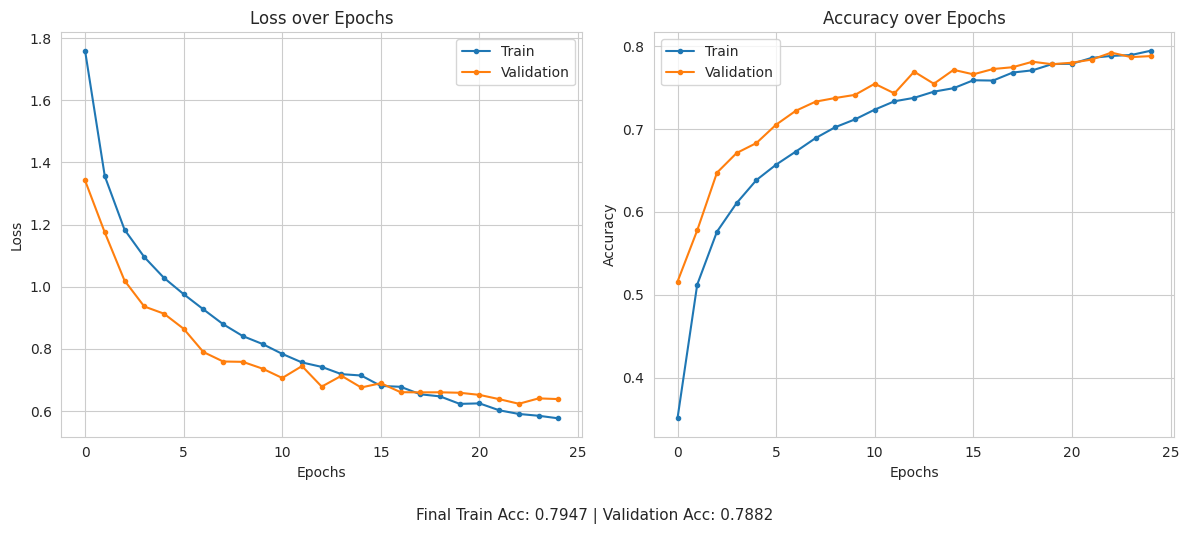

In [43]:
plot_training_history(history_dropout)

The improved architecture with additional convolutional layers and dropout significantly enhances the model performance. The validation accuracy reaches 78.8%, showing a substantial improvement compared to previous models. Both training and validation loss decrease smoothly, and the gap between training and validation accuracy is minimal, indicating good generalization and no strong overfitting. The training process is stable, and the model is able to learn more expressive features while maintaining robustness. Overall, this architecture provides the best performance among the tested models.

In [44]:
y_true = np.argmax(y_test, axis=1)
y_pred_dropout = np.argmax(model_dropout.predict(x_test), axis=1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step


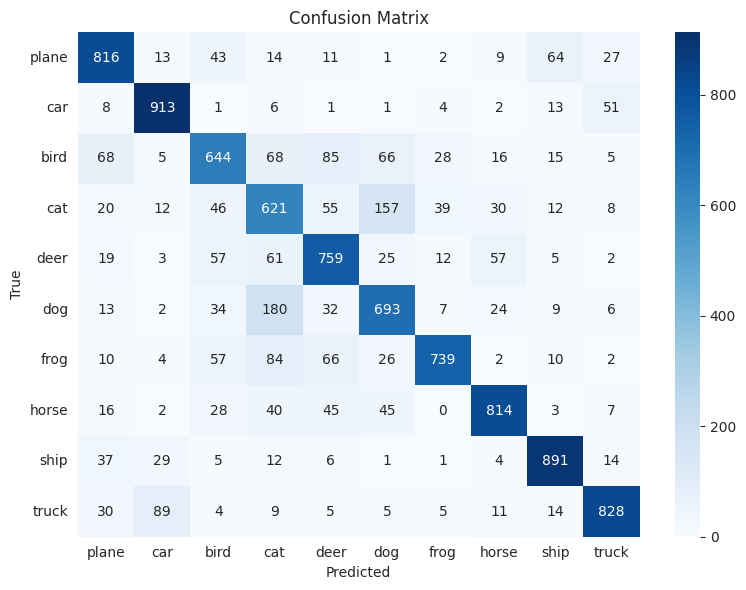

In [45]:
plot_confusion_matrix(y_true, y_pred_dropout, classes)

In [46]:
build_metrics_table(history_dropout, model_dropout, x_test, y_test)

,Dataset,Loss,Accuracy
0,Train,0.576500,0.794700
1,Validation,0.638400,0.788200
2,Test,0.684400,0.771800


In [47]:
compute_class_accuracy(y_true, y_pred_dropout, classes)

,Class,Accuracy
0,car,0.913
1,ship,0.891
2,truck,0.828
3,plane,0.816
4,horse,0.814
5,deer,0.759
6,frog,0.739
7,dog,0.693
8,bird,0.644
9,cat,0.621


#### Model4: Examples of Correct Predictions

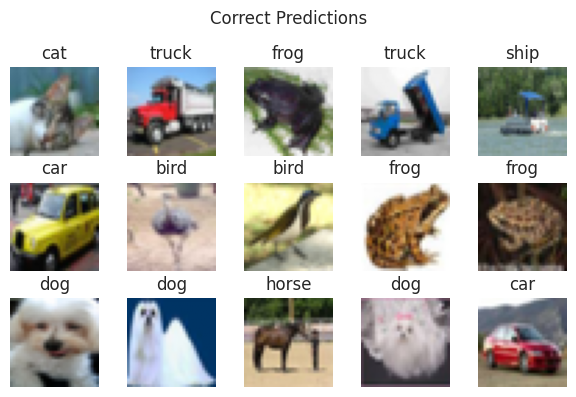

In [71]:
show_predictions(x_test, y_true, y_pred_dropout, classes, mode='correct')

#### Model4: Examples of Misclassified Samples

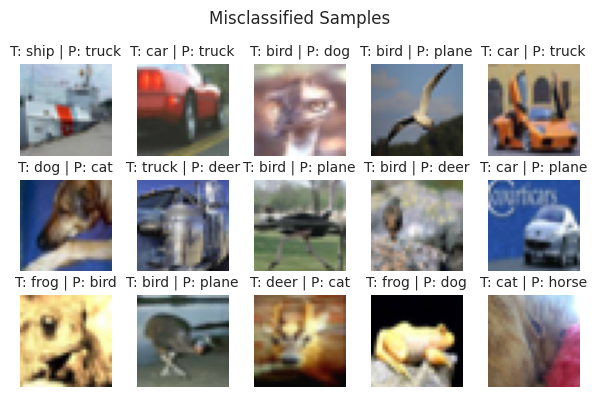

In [68]:
show_predictions(x_test, y_true, y_pred_dropout, classes, mode='wrong')

The final model achieves a test accuracy of 77.2%, showing a significant improvement over previous architectures. The gap between training, validation, and test accuracy is small, indicating good generalization and stable performance on unseen data.

The confusion matrix and class-wise accuracy demonstrate improved performance across all classes, including previously challenging ones such as cat, dog, and bird. While these classes remain more difficult compared to visually distinct categories like car and ship, their accuracy has noticeably increased, indicating better feature extraction and discrimination.

Overall, the model successfully balances capacity and regularization, leading to more robust and consistent predictions across different classes.

## Model 5: + Data Augmentation

Data augmentation is applied to increase data variability and enhance robustness to input transformations.

In [55]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomTranslation(0.1, 0.1),
])

In [57]:
inputs = Input(shape=(32, 32, 3))

x = data_augmentation(inputs)

# Block 1
x = Conv2D(32, (3,3), activation='relu', padding='same')(x)
x = Conv2D(32, (3,3), activation='relu', padding='same')(x)
x = MaxPooling2D((2,2))(x)
x = Dropout(0.25)(x)

# Block 2
x = Conv2D(64, (3,3), activation='relu', padding='same')(x)
x = Conv2D(64, (3,3), activation='relu', padding='same')(x)
x = MaxPooling2D((2,2))(x)
x = Dropout(0.25)(x)

# Classifier
x = Flatten()(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.5)(x)

outputs = Dense(num_classes, activation='softmax')(x)

model_aug = Model(inputs, outputs)

model_aug.summary()

Model: "functional_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_10 (InputLayer)     │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_1 (Sequential)       │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_24 (Conv2D)              │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_25 (Conv2D)              │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_15 (MaxPooling2D) │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_26 (Conv2D)              │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_27 (Conv2D)              │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_16 (MaxPooling2D) │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_7 (Flatten)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 128)            │       524,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 591,274 (2.26 MB)

 Trainable params: 591,274 (2.26 MB)

 Non-trainable params: 0 (0.00 B)

In [58]:
epochs = 25
batch_size = 128

# Compile the model
model_aug.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Train the model
history_aug = model_aug.fit(
    x_train,
    y_train,
    validation_split=0.1,
    epochs=epochs,
    batch_size=batch_size
)

Epoch 1/25
352/352 ━━━━━━━━━━━━━━━━━━━━ 38s 106ms/step - accuracy: 0.3286 - loss: 1.8283 - val_accuracy: 0.4864 - val_loss: 1.4134
Epoch 2/25
352/352 ━━━━━━━━━━━━━━━━━━━━ 42s 119ms/step - accuracy: 0.4457 - loss: 1.5143 - val_accuracy: 0.5140 - val_loss: 1.3507
Epoch 3/25
352/352 ━━━━━━━━━━━━━━━━━━━━ 43s 122ms/step - accuracy: 0.5075 - loss: 1.3672 - val_accuracy: 0.5910 - val_loss: 1.1511
Epoch 4/25
352/352 ━━━━━━━━━━━━━━━━━━━━ 42s 120ms/step - accuracy: 0.5427 - loss: 1.2734 - val_accuracy: 0.6172 - val_loss: 1.0830
Epoch 5/25
352/352 ━━━━━━━━━━━━━━━━━━━━ 42s 120ms/step - accuracy: 0.5805 - loss: 1.1823 - val_accuracy: 0.6480 - val_loss: 1.0195
Epoch 6/25
352/352 ━━━━━━━━━━━━━━━━━━━━ 42s 120ms/step - accuracy: 0.5992 - loss: 1.1307 - val_accuracy: 0.6664 - val_loss: 0.9619
Epoch 7/25
352/352 ━━━━━━━━━━━━━━━━━━━━ 42s 120ms/step - accuracy: 0.6213 - loss: 1.0781 - val_accuracy: 0.6928 - val_loss: 0.8842
Epoch 8/25
352/352 ━━━━━━━━━━━━━━━━━━━━ 43s 121ms/step - accuracy: 0.6380 - loss: 1

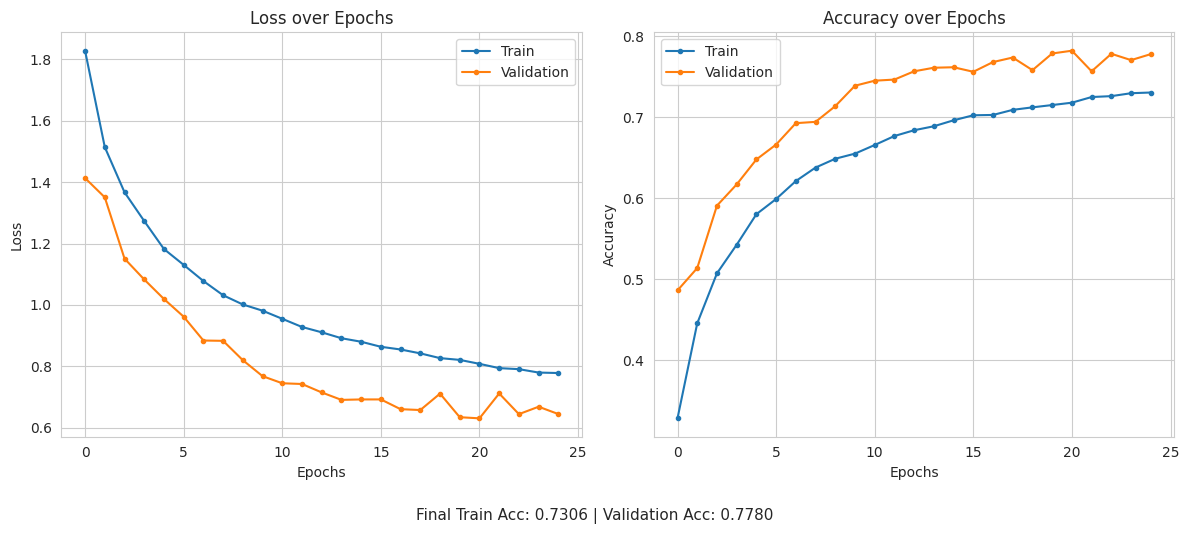

In [59]:
plot_training_history(history_aug)

Training accuracy is lower compared to the previous model, as data augmentation increases input variability and makes the learning task more challenging.

In [60]:
y_true = np.argmax(y_test, axis=1)
y_pred_aug = np.argmax(model_aug.predict(x_test), axis=1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step


In [61]:
build_metrics_table(history_aug, model_aug, x_test, y_test)

,Dataset,Loss,Accuracy
0,Train,0.778300,0.730600
1,Validation,0.644700,0.778000
2,Test,0.657700,0.778500


In [62]:
compute_class_accuracy(y_true, y_pred_aug, classes)

,Class,Accuracy
0,car,0.942
1,frog,0.939
2,truck,0.921
3,horse,0.839
4,ship,0.815
5,plane,0.800
6,deer,0.725
7,dog,0.718
8,bird,0.561
9,cat,0.525


#### Model5: Examples of Correct Predictions

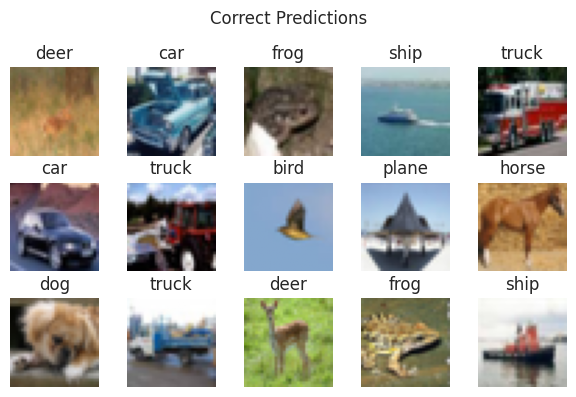

In [73]:
show_predictions(x_test, y_true, y_pred_aug, classes, mode='correct')

#### Model5: Examples of Misclassified Samples

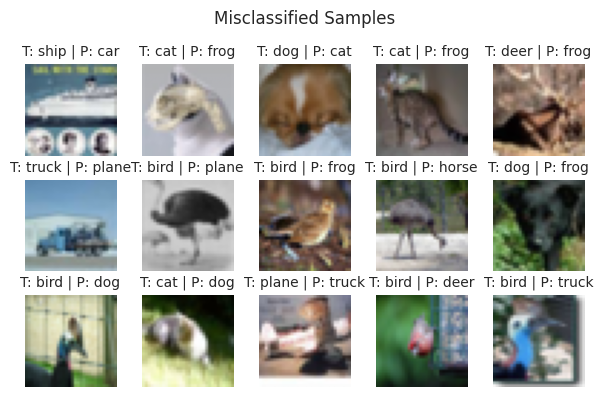

In [74]:
show_predictions(x_test, y_true, y_pred_aug, classes, mode='wrong')

Data augmentation resulted in a very slight increase in test accuracy; however, the improvement is marginal and within the range of random variation. At the same time, training accuracy decreased, indicating that the task became more difficult. Overall, augmentation did not provide a significant benefit, suggesting that the model was already well-regularized and did not require additional data transformations.

## Model Comparison

In [63]:
def collect_model_metrics(name, history, model, x_test, y_test):
    import pandas as pd

    train_acc = history.history['accuracy'][-1]
    val_acc = history.history['val_accuracy'][-1]
    test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)

    return pd.DataFrame({
        'Model': [name],
        'Train Acc': [train_acc],
        'Val Acc': [val_acc],
        'Test Acc': [test_acc]
    })

In [64]:
df_all = pd.concat([
    collect_model_metrics('Baseline', history_baseline, model_baseline, x_test, y_test),
    collect_model_metrics('+ Filters', history_filters, model_filters, x_test, y_test),
    collect_model_metrics('+ BatchNorm', history_bn, model_bn, x_test, y_test),
    collect_model_metrics('+ Dropout', history_dropout, model_dropout, x_test, y_test),
    collect_model_metrics('+ Augmentation', history_aug, model_aug, x_test, y_test),
], ignore_index=True)

df_all = df_all.round(4)
df_all

,Model,Train Acc,Val Acc,Test Acc
0,Baseline,0.7058,0.6690,0.6649
1,+ Filters,0.7848,0.7006,0.6933
2,+ BatchNorm,0.8615,0.5968,0.5996
3,+ Dropout,0.7947,0.7882,0.7718
4,+ Augmentation,0.7306,0.7780,0.7785


# Conclusion

The baseline model achieved moderate performance, indicating that the initial architecture was able to capture basic patterns in the data. Increasing the number of filters improved all metrics, showing that a higher model capacity helps extract more informative features. However, adding Batch Normalization significantly degraded validation and test performance, despite increasing training accuracy, which indicates strong overfitting and unstable training dynamics in this setup.

Introducing Dropout led to the best overall performance, with validation and test accuracy becoming closely aligned, demonstrating improved generalization. This modification increased the test accuracy from approximately 66% to 77.8%, making it the most effective improvement. Finally, data augmentation resulted in only a marginal improvement in test accuracy, suggesting that the model was already sufficiently regularized and did not benefit significantly from additional data transformations.

Overall, convolutional neural networks proved to be well-suited for this task, as they effectively capture spatial hierarchies and local patterns in images. Their ability to learn increasingly complex features through stacked convolutional layers makes them particularly suitable for image classification problems such as CIFAR-10. The results demonstrate that even relatively simple CNN architectures can achieve strong performance when properly designed and regularized.